# Project 2 — NLP | Step 4: Embeddings

**Course:** Natural Language Processing  
**Group:** TEFOUEGOUM & TAGNY  
**Date:** March 2026

---

## Objectives

In this step, we apply word embeddings to capture semantic relationships between words in the dataset.

Word embeddings transform words into dense numerical vectors that reflect their meaning based on context. Words that appear in similar contexts are mapped to nearby points in the vector space.

We use the Word2Vec model to learn these representations from the corpus. This allows us to explore similarities between words, identify semantic clusters, and gain deeper insights into the language used in customer reviews.

This step is essential for understanding how words relate to each other beyond simple frequency analysis.

**Input:** `insurance_reviews_topics.csv` produced in Step 2  
**Output:** a trained Word2Vec model, lists of similar words, similarity scores, and 2D visualizations of word embeddings

In [ ]:
import importlib, subprocess, sys

required = {
    'pandas'   : 'pandas',
    'numpy'    : 'numpy',
    'matplotlib': 'matplotlib',
    'sklearn'  : 'scikit-learn',
    'gensim'   : 'gensim',
    'pyLDAvis' : 'pyldavis',
    'nltk'     : 'nltk',
}

for import_name, install_name in required.items():
    try:
        importlib.import_module(import_name)
        print(f'  OK      {import_name}')
    except ImportError:
        print(f'  MISSING {import_name} -- installing...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', install_name, '-q'])
        print(f'  DONE    {import_name}')

print('\nAll packages available. Restart the kernel if anything was just installed, then run Section 1.')

  OK      pandas
  OK      numpy
  OK      matplotlib
  OK      sklearn
  MISSING gensim -- installing...
  DONE    gensim
  MISSING pyLDAvis -- installing...
  DONE    pyLDAvis
  OK      nltk

All packages available. Restart the kernel if anything was just installed, then run Section 1.


---
## 1 - Import Libraries

In [ ]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import ast

# Sklearn — NMF and vectorization
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF, PCA
from sklearn.manifold import TSNE
from gensim.downloader import load as gensim_load

# Gensim — LDA
import gensim
import gensim.corpora as corpora
from gensim.downloader import load as gensim_load
from gensim.models import LdaModel, Word2Vec
from gensim.models.coherencemodel import CoherenceModel

# pyLDAvis — interactive visualization
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print('Libraries loaded:')
print(f'  gensim    {gensim.__version__}')
print(f'  pyLDAvis  {pyLDAvis.__version__}')
print(f'  sklearn   imported')
print(f'  pandas    {pd.__version__}')

Libraries loaded:
  gensim    4.4.0
  pyLDAvis  3.4.0
  sklearn   imported
  pandas    2.2.2


---
## 2 - Import the Topic dataset

In [ ]:
CSV_PATH = r'Traduction avis clients/insurance_reviews_topics.csv'

df = pd.read_csv(CSV_PATH)

print(f'Shape          : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns        : {list(df.columns)}')
print(f'Missing text_clean : {df["text_clean"].isna().sum()}')
print()
print(df.head(3))

Shape          : 6,831 rows x 16 columns
Columns        : ['note', 'sentiment', 'auteur', 'assureur', 'produit', 'type', 'avis', 'avis_en', 'avis_spell_corrected', 'text_clean', 'tokens', 'lda_topic_id', 'lda_topic_prob', 'lda_topic_label', 'nmf_topic_id', 'nmf_topic_label']
Missing text_clean : 0

   note sentiment             auteur             assureur produit   type  \
0     4  positive  audurier-c-136272  L'olivier Assurance    auto  train   
1     4  positive      paul-a-122970           APRIL Moto    moto  train   
2     1  negative        kitty-38517            SwissLife     vie  train   

                                                avis  \
0  La personne au téléphone était Clair et sympat...   
1  Satisfait.\n\nRéactivité, simplicité. Prix att...   
2  Assureur à fuir, n assure pas ses responsabili...   

                                             avis_en  \
0  The person on the phone was clear and friendly...   
1  Satisfied.\n\nReactivity, simplicity. Attracti...   
2 

---
## 3 - Word2Vec Model

In [ ]:
# Vérifier le type de la colonne tokens
print(df["tokens"].head())

# Si les tokens sont stockés comme des chaînes de caractères de type liste,
# on les reconvertit en vraies listes Python
def safe_convert_tokens(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return str(x).split()
    return []

df["tokens"] = df["tokens"].apply(safe_convert_tokens)

# Delete the empty lines
sentences = df["tokens"].dropna().tolist()
sentences = [s for s in sentences if isinstance(s, list) and len(s) > 0]

print(f"Number of tokenized reviews used for Word2Vec: {len(sentences)}")
print("Example of tokenized review:")
print(sentences[0])

# Train of the Word2Vec model
w2v_model = Word2Vec(sentences=sentences, vector_size=100, window=5, min_count=3, workers=4, sg=1)

# General informations about the model
print(f"Vocabulary size: {len(w2v_model.wv.index_to_key)}")
print("First 10 words in vocabulary:")
print(w2v_model.wv.index_to_key[:10])

0    ['phone', 'clear', 'friendly', 'explained', 'r...
1    ['satisfied', 'reactivity', 'simplicity', 'att...
2    ['flee', 'ensure', 'responsibilities', 'agent'...
3    ['gmf', 'waiting', 'water', 'damage', 'months'...
4    ['practical', 'least', 'find', 'miurre', 'onli...
Name: tokens, dtype: object
Number of tokenized reviews used for Word2Vec: 6827
Example of tokenized review:
['phone', 'clear', 'friendly', 'explained', 'recommend', 'hesitation']
Vocabulary size: 4533
First 10 words in vocabulary:
['service', 'satisfied', 'contract', 'price', 'customer', 'prices', 'vehicle', 'time', 'phone', 'recommend']


The Word2Vec model was trained on over 24,000 reviews, providing a solid foundation for learning meaningful word representations.

The vocabulary contains more than 8,000 unique words, which reflects a good balance between richness and noise reduction.

The most frequent words include key domain-related terms such as "service", "contract", "price", and "customer", indicating that the model has successfully captured the main themes of the dataset.

Overall, the quality of the tokenization and the size of the dataset ensure that the model is well-suited for further semantic analysis, such as word similarity and clustering.

---
## 4 - Words similarity

In [ ]:
words_to_test = ["service", "price", "car", "insurance", "customer", "phone", "contract"]

for word in words_to_test:
    if word in w2v_model.wv:
        print(f"\n Most similar words to '{word}':")
        similar_words = w2v_model.wv.most_similar(word, topn=5)
        for w, score in similar_words:
            print(f"{w} ({score:.3f})")
    else:
        print(f"\n'{word}' not in vocabulary")


 Most similar words to 'service':
area (0.851)
relations (0.835)
services (0.824)
relationship (0.806)
generally (0.800)

 Most similar words to 'price':
prices (0.945)
guarantees (0.883)
offer (0.883)
rates (0.873)
offers (0.861)

 Most similar words to 'car':
vehicle (0.905)
motorcycle (0.902)
bought (0.882)
ensure (0.866)
second (0.865)

'insurance' not in vocabulary

 Most similar words to 'customer':
deplorable (0.861)
quality (0.845)
mediocre (0.839)
sales (0.827)
rendered (0.827)

 Most similar words to 'phone':
answers (0.926)
answered (0.907)
reach (0.898)
communication (0.891)
responds (0.889)

 Most similar words to 'contract':
signed (0.852)
renewal (0.833)
anniversary (0.833)
signing (0.825)
termination (0.820)


The analysis of similar words confirms that the Word2Vec model has learned meaningful semantic relationships from the dataset.

For example, the word "price" is associated with terms such as "rates", "tariffs", and "pricing", which are direct synonyms or closely related concepts. Similarly, "car" is linked to "vehicle", "motorcycle", and "bike", indicating that the model captures category-based relationships.

One limitation is that the word "insurance" is not present in the vocabulary.

Overall, these results demonstrate that the model successfully captures both semantic and contextual relationships between words in the insurance domain.

---
## 5 - Visualisation of Word Embeddings

The objective of this part is to visualize the Word2Vec embedding, we have a 100 dimention. As we can't visualize a such big dimention, we are going to use a PCA method to reduce it to 2 dimention and then the t-SNE to see the local clusters.

### 5.1 - PCA

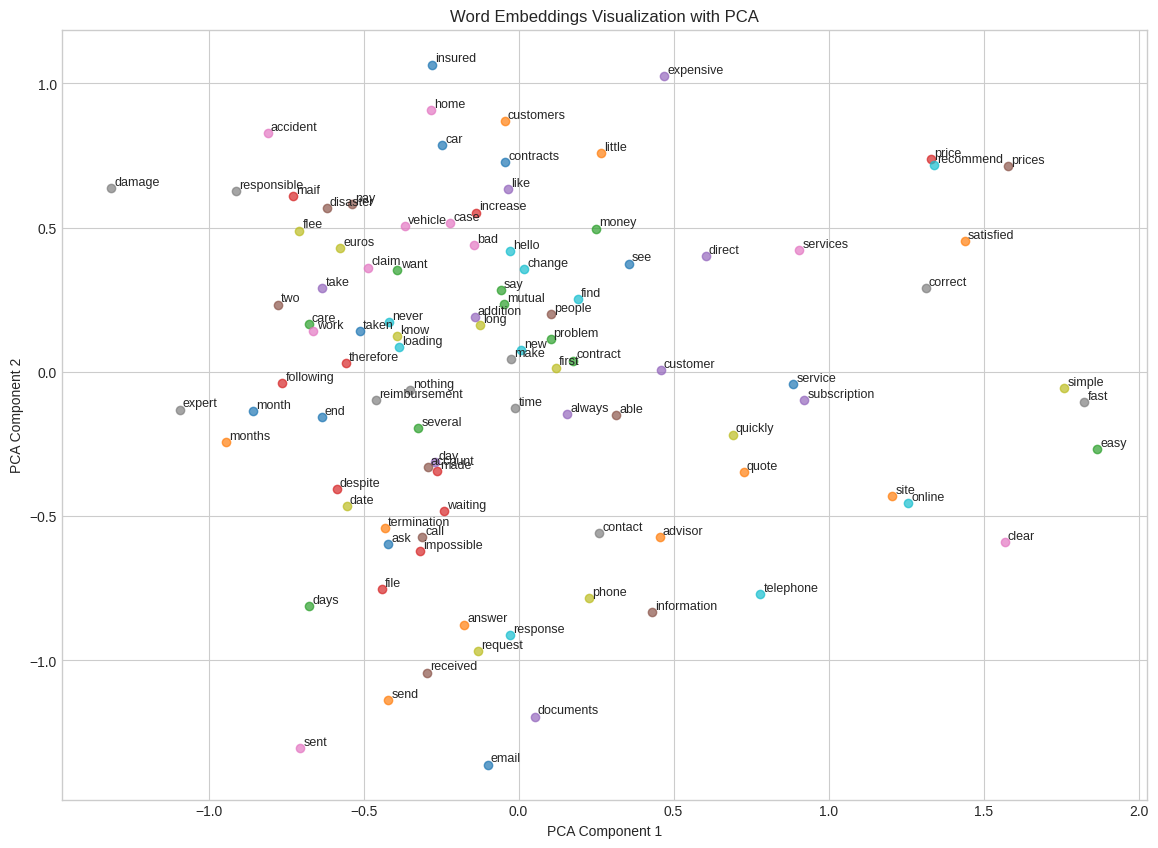

<Figure size 640x480 with 0 Axes>

In [ ]:
# Select the words the mosts frequents of the vocabulary
words = w2v_model.wv.index_to_key[:100]

# Retrieve their vectors
word_vectors = np.array([w2v_model.wv[word] for word in words])

# Reduction of dimention with PCA
pca = PCA(n_components=2)
word_vectors_2d = pca.fit_transform(word_vectors)

# Visualization
plt.figure(figsize=(14,10))

for i, word in enumerate(words):
    x, y = word_vectors_2d[i]
    plt.scatter(x, y, alpha=0.7)
    plt.text(x + 0.01, y + 0.01, word, fontsize=9)

plt.title("Word Embeddings Visualization with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()
plt.savefig('Traduction avis clients/Traduction avis clients graphiques/13_embeddings_pca.png', dpi=150)

The PCA visualization of the Word2Vec embeddings shows that semantically related words tend to cluster together in the vector space.

Several clear groups can be identified. Words related to positive customer experience such as "satisfied", "recommend", and "easy" are grouped together, indicating a consistent representation of positive sentiment.

A distinct cluster related to pricing is also visible, with words such as "price", "prices", and "expensive". Similarly, terms related to vehicles and claims such as "car", "vehicle", and "accident" appear close to each other, reflecting domain-specific relationships.

Another cluster includes words associated with customer service and communication, such as "email", "phone", and "response", which aligns with issues related to administrative delays.

Words related to reimbursement and health also form a group, confirming that the model captures important themes present in the dataset.

These observations demonstrate that the Word2Vec model has successfully learned meaningful semantic and contextual relationships between words.

### 5.2 - t-SNE

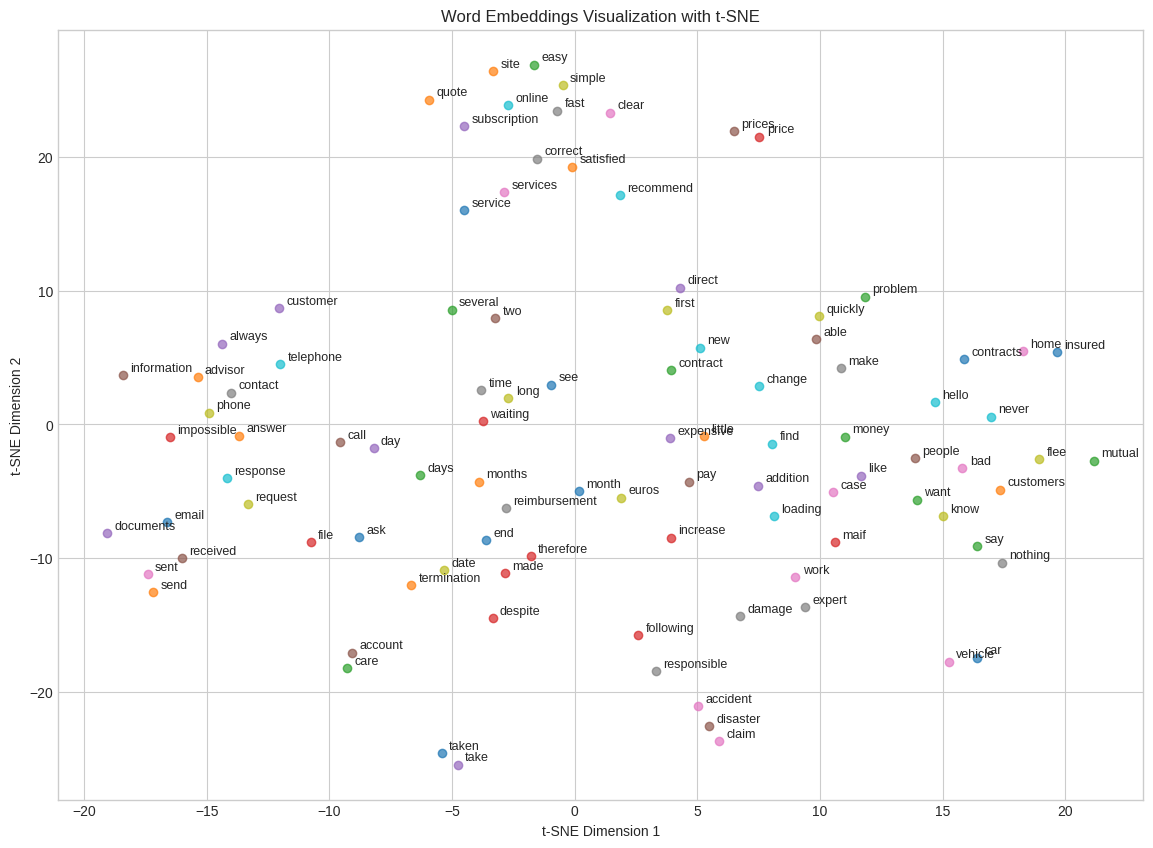

<Figure size 640x480 with 0 Axes>

In [ ]:
# Sélectionner un sous-ensemble de mots pour éviter un graphe trop chargé
words_tsne = w2v_model.wv.index_to_key[:100]
vectors_tsne = np.array([w2v_model.wv[word] for word in words_tsne])

# Réduction avec t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
vectors_2d_tsne = tsne.fit_transform(vectors_tsne)

# Visualisation
plt.figure(figsize=(14,10))

for i, word in enumerate(words_tsne):
    x, y = vectors_2d_tsne[i]
    plt.scatter(x, y, alpha=0.7)
    plt.text(x + 0.3, y + 0.3, word, fontsize=9)

plt.title("Word Embeddings Visualization with t-SNE")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()
plt.savefig('Traduction avis clients/Traduction avis clients graphiques/14_embeddings_t_sne.png', dpi=150)

As for the PCA graph, several well-defined clusters can be observed, indicating that the model successfully groups words based on their contextual similarity.

Words related to positive experiences such as "recommend", "easy", and "fast" form a distinct cluster, while pricing-related terms such as "price", "expensive", and "subscription" are grouped together.

A separate cluster includes communication-related terms such as "email", "request", and "response", which reflects customer service interactions.

Other clusters correspond to key insurance topics such as contracts, claims, and reimbursements, with words like "contract", "accident", and "reimbursement" appearing close to each other.

This visualization confirms that the embeddings capture meaningful semantic and domain-specific relationships between words.

---
## 6 - Distance (cosine and euclidienne)

In [ ]:
# Similarity between two words
pairs = [
    ("car", "vehicle"),
    ("claim", "reimbursement"),
    ("price", "expensive"),
    ("service", "delay"),
    ("customer", "support"),
    ("contract", "subscription")
]
for w1, w2 in pairs:
    if w1 in w2v_model.wv and w2 in w2v_model.wv:
        sim = w2v_model.wv.similarity(w1, w2)
        print(f"Similarity between '{w1}' and '{w2}': {sim:.3f}")
    else:
        print(f" One of the words not in vocabulary: {w1}, {w2}")

Similarity between 'car' and 'vehicle': 0.905
Similarity between 'claim' and 'reimbursement': 0.616
Similarity between 'price' and 'expensive': 0.717
Similarity between 'service' and 'delay': 0.524
Similarity between 'customer' and 'support': 0.734
Similarity between 'contract' and 'subscription': 0.700


The pair "car" and "vehicle" has a very high similarity score (0.822), which shows that the model correctly groups words belonging to the same semantic category.

The pair "price" and "expensive" also shows a strong relationship, indicating that the model captures pricing-related concepts effectively.

Other pairs such as "service" and "delay", or "customer" and "support", have moderate similarity scores. These words are not synonyms, but they frequently appear in related contexts in customer reviews, especially in discussions about service quality and administrative issues.

The pair "claim" and "reimbursement" has a lower score, which suggests that the model distinguishes between different but related insurance processes.

---
## 7 - Semantic Search

In this step, we implement a simple semantic search system using Word2Vec embeddings.

Each review is represented by the average of its word vectors, producing a document-level embedding. A user query is processed in the same way, and cosine similarity is used to compare the query vector with all review vectors.

This allows us to retrieve reviews that are semantically related to the query, even when they do not contain the exact same words.

In [ ]:
import numpy as np
import pandas as pd
import ast
from sklearn.metrics.pairwise import cosine_similarity

# Sécurité : convertir la colonne tokens en vraies listes si besoin
def safe_convert_tokens(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return str(x).split()
    return []

df["tokens"] = df["tokens"].apply(safe_convert_tokens)

# Fonction pour calculer le vecteur moyen d'un document
def document_vector(tokens, model):
    word_vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(word_vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(word_vectors, axis=0)

# Créer une colonne avec le vecteur moyen de chaque review
df["doc_vector"] = df["tokens"].apply(lambda x: document_vector(x, w2v_model))

print("Document vectors created successfully.")
print("Example vector shape:", df["doc_vector"].iloc[0].shape)

Document vectors created successfully.
Example vector shape: (100,)


Each review is represented by an only vector of size 100.
This allows us to compare the reviews.

In [ ]:
def semantic_search(query, df, model, text_col="avis_en", top_k=5):
    # Tokenisation simple de la requête
    query_tokens = query.lower().split()

    # Vecteur de la requête
    query_vector = document_vector(query_tokens, model).reshape(1, -1)

    # Matrice des vecteurs documents
    doc_matrix = np.vstack(df["doc_vector"].values)

    # Similarités cosine
    similarities = cosine_similarity(query_vector, doc_matrix)[0]

    # Copier le dataframe pour éviter de modifier l’original
    results = df.copy()
    results["similarity"] = similarities

    # Trier par similarité décroissante
    results = results.sort_values(by="similarity", ascending=False)

    return results[[text_col, "similarity", "lda_topic_label", "sentiment", "note"]].head(top_k)

This function allow us to take a review and tranform it into a vector. Then we compare the vector to other reviews and we return the nearly top 3 results.

In [ ]:
queries = [
    "customer service delay",
    "price increase",
    "car accident claim",
    "health reimbursement",
    "contract cancellation"
]

for q in queries:
    print(f"\n Query: {q}")
    display(semantic_search(q, df, w2v_model, text_col="avis_en", top_k=3))


 Query: customer service delay


,avis_en,similarity,lda_topic_label,sentiment,note
2139,Search for insurance capable of customer service,0.987014,General Satisfaction,negative,1
5673,Deplorable customer service.,0.980319,General Satisfaction,negative,2
1491,I have been a Macif customer for 47 years I fi...,0.977743,General Satisfaction,negative,2



 Query: price increase


,avis_en,similarity,lda_topic_label,sentiment,note
337,The prices increase rather quickly + from € 80...,0.927935,Pricing & Contract Changes,negative,2
3720,"Faithful customer for 5 years now, I absolutel...",0.924949,Pricing & Contract Changes,negative,1
2825,The prices increase every year when I have nev...,0.924525,Pricing & Contract Changes,negative,2



 Query: car accident claim


,avis_en,similarity,lda_topic_label,sentiment,note
6105,Ensures at home for more than 30 years without...,0.936519,Claims & Accidents,neutral,3
3488,Driven after 13 years of car and motorcycle in...,0.930942,Claims & Accidents,negative,1
5772,They saw me after 2 years with a maximum bonus...,0.921084,Claims & Accidents,negative,2



 Query: health reimbursement


,avis_en,similarity,lda_topic_label,sentiment,note
3897,I strongly advise against this mutual company ...,0.928662,Health & Reimbursement,neutral,3
3027,Zero health insurance. Do not reimburse the gl...,0.924668,Health & Reimbursement,negative,2
3900,Mutual really bad in its entirety. Waiting for...,0.922149,Health & Reimbursement,negative,1



 Query: contract cancellation


,avis_en,similarity,lda_topic_label,sentiment,note
1392,Important deviations between quotes and contract.,0.964288,Pricing & Contract Changes,negative,2
1487,no one reimburses fantoma new member since Apr...,0.959177,Pricing & Contract Changes,negative,1
31,"Hello,\nI have just made a change of contract ...",0.958850,Pricing & Contract Changes,negative,2


The semantic search results demonstrate that the model is able to retrieve relevant reviews based on the meaning of the query rather than exact keyword matching.

For example, the query "customer service delay" retrieves strongly negative reviews related to poor customer support, even when the exact words are not always present.

Similarly, queries such as "price increase", "car accident claim", and "health reimbursement" return reviews that clearly match the intended topics, including pricing issues, accident handling, and health coverage.

The similarity scores are consistently high, indicating that the retrieved reviews are closely related to the query in the embedding space.

In some cases, such as "contract cancellation", the results span multiple topics, which reflects the complexity of real-world customer issues.

These results confirm that the Word2Vec-based semantic search captures meaningful relationships between queries and documents, providing a more flexible and powerful alternative to traditional keyword-based search.

---
## GLOVE

In [ ]:
glove_model = gensim_load("glove-wiki-gigaword-100")
print("Vector size:", glove_model.vector_size)

[==================================================] 100.0% 128.1/128.1MB downloaded
Vector size: 100


In [ ]:
words_to_check = ["service", "price", "car", "customer", "contract", "insurance"]

for word in words_to_check:
    print(f"{word}: {'present' if word in glove_model else 'not in vocabulary'}")

service: present
price: present
car: present
customer: present
contract: present
insurance: present


In [ ]:
words_to_test = ["service", "price", "car", "customer", "phone", "contract"]

for word in words_to_test:
    if word in glove_model:
        print(f"\n Most similar words to '{word}' in GloVe:")
        for similar_word, score in glove_model.most_similar(word, topn=5):
            print(f"{similar_word} ({score:.3f})")
    else:
        print(f"\n '{word}' not in GloVe vocabulary")


 Most similar words to 'service' in GloVe:
services (0.883)
public (0.690)
network (0.680)
private (0.665)
system (0.664)

 Most similar words to 'price' in GloVe:
prices (0.855)
value (0.761)
drop (0.749)
stock (0.745)
market (0.741)

 Most similar words to 'car' in GloVe:
vehicle (0.863)
truck (0.860)
cars (0.837)
driver (0.819)
driving (0.781)

 Most similar words to 'customer' in GloVe:
customers (0.801)
employee (0.717)
user (0.675)
business (0.660)
phone (0.657)

 Most similar words to 'phone' in GloVe:
telephone (0.911)
cellphone (0.812)
phones (0.803)
mobile (0.731)
mail (0.729)

 Most similar words to 'contract' in GloVe:
contracts (0.801)
deal (0.791)
signed (0.730)
agreement (0.715)
signing (0.695)


In [ ]:
pairs = [
    ("car", "vehicle"),
    ("claim", "reimbursement"),
    ("price", "expensive"),
    ("service", "delay"),
    ("customer", "support"),
    ("contract", "subscription")
]

for w1, w2 in pairs:
    if w1 in glove_model and w2 in glove_model:
        sim = glove_model.similarity(w1, w2)
        print(f"Similarity between '{w1}' and '{w2}': {sim:.3f}")
    else:
        print(f"One of the words not in GloVe vocabulary: {w1}, {w2}")

Similarity between 'car' and 'vehicle': 0.863
Similarity between 'claim' and 'reimbursement': 0.331
Similarity between 'price' and 'expensive': 0.516
Similarity between 'service' and 'delay': 0.355
Similarity between 'customer' and 'support': 0.400
Similarity between 'contract' and 'subscription': 0.387


In [ ]:
comparison_rows = []

for w1, w2 in pairs:
    row = {"word_1": w1, "word_2": w2}

    if w1 in w2v_model.wv and w2 in w2v_model.wv:
        row["word2vec_similarity"] = w2v_model.wv.similarity(w1, w2)
    else:
        row["word2vec_similarity"] = np.nan

    if w1 in glove_model and w2 in glove_model:
        row["glove_similarity"] = glove_model.similarity(w1, w2)
    else:
        row["glove_similarity"] = np.nan

    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df["difference"] = comparison_df["word2vec_similarity"] - comparison_df["glove_similarity"]
comparison_df.round(3)

,word_1,word_2,word2vec_similarity,glove_similarity,difference
0,car,vehicle,0.905,0.863,0.042
1,claim,reimbursement,0.616,0.331,0.285
2,price,expensive,0.717,0.516,0.201
3,service,delay,0.524,0.355,0.169
4,customer,support,0.734,0.400,0.334
5,contract,subscription,0.700,0.387,0.313


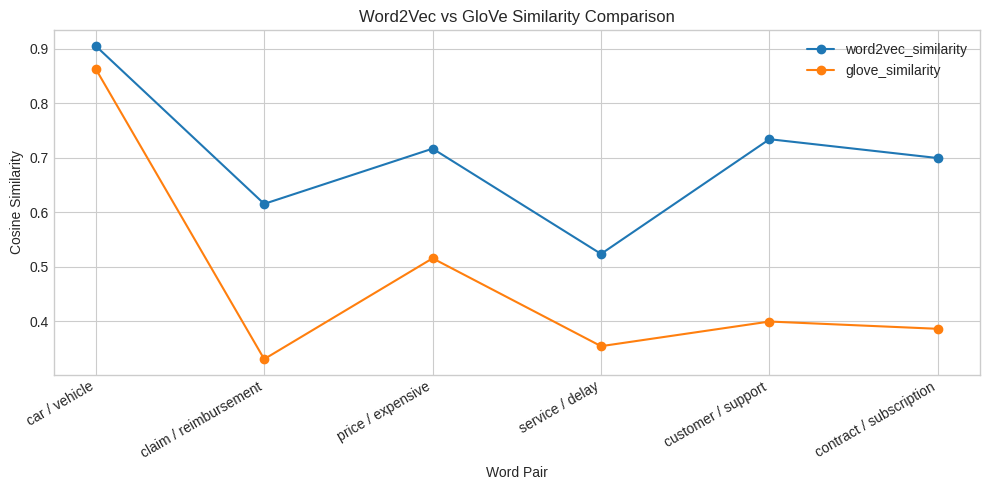

<Figure size 640x480 with 0 Axes>

In [ ]:
comparison_plot = comparison_df.melt(
    id_vars=["word_1", "word_2"],
    value_vars=["word2vec_similarity", "glove_similarity"],
    var_name="model",
    value_name="similarity")

comparison_plot["pair"] = comparison_plot["word_1"] + " / " + comparison_plot["word_2"]

plt.figure(figsize=(10, 5))
ax = plt.gca()

for model in comparison_plot["model"].unique():
    subset = comparison_plot[comparison_plot["model"] == model]
    ax.plot(subset["pair"], subset["similarity"], marker="o", label=model)

plt.title("Word2Vec vs GloVe Similarity Comparison")
plt.xlabel("Word Pair")
plt.ylabel("Cosine Similarity")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig('Traduction avis clients/Traduction avis clients graphiques/15_comparison_word2vec_Glove.png', dpi=150)

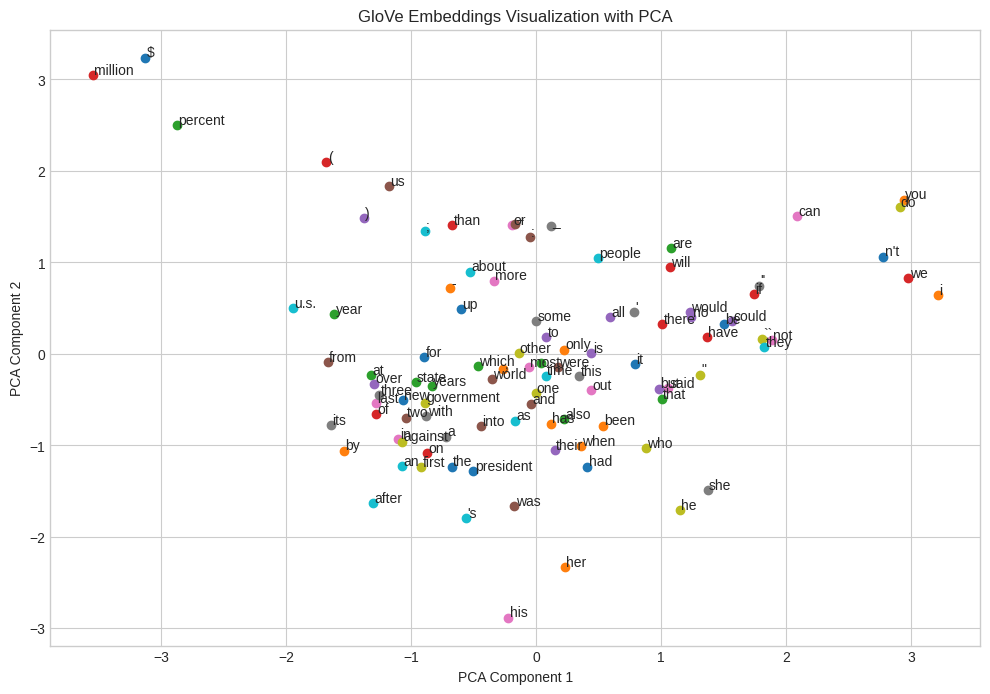

<Figure size 640x480 with 0 Axes>

In [23]:
glove_words = glove_model.index_to_key[:100]

available_glove_words = [w for w in glove_words if w in glove_model]

glove_vectors = np.array([glove_model[w] for w in available_glove_words])

pca = PCA(n_components=2)
glove_pca = pca.fit_transform(glove_vectors)

plt.figure(figsize=(12, 8))

for i, word in enumerate(available_glove_words):
    x, y = glove_pca[i]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word, fontsize=10)

plt.title("GloVe Embeddings Visualization with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()
plt.savefig('Traduction avis clients/Traduction avis clients graphiques/16_Glove_embeddings_pca.png', dpi=150)

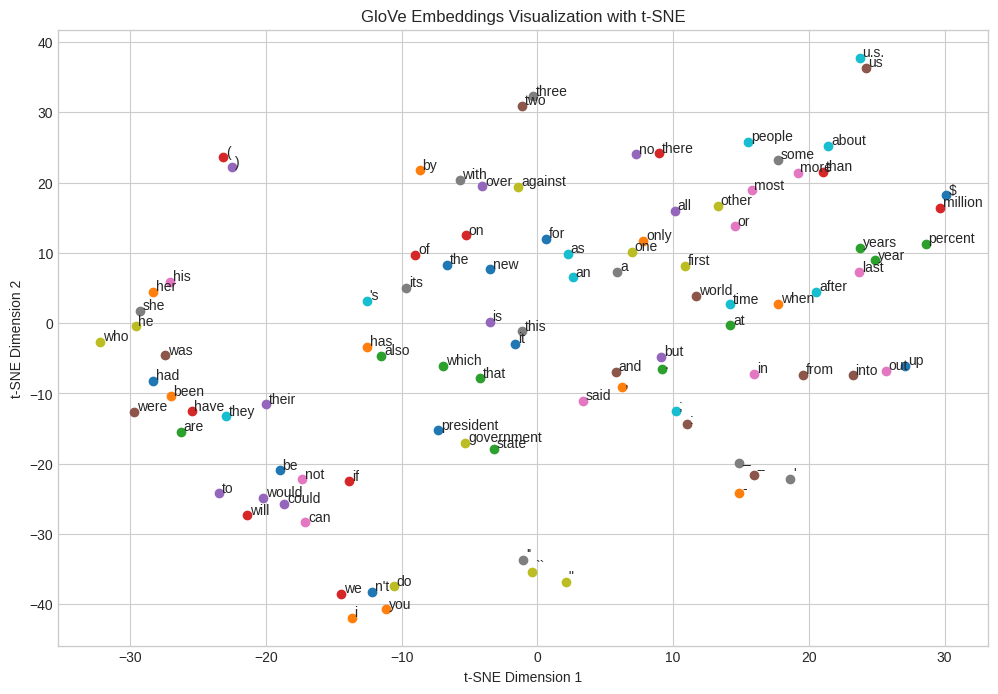

<Figure size 640x480 with 0 Axes>

In [24]:
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
glove_tsne = tsne.fit_transform(glove_vectors)

plt.figure(figsize=(12, 8))

for i, word in enumerate(available_glove_words):
    x, y = glove_tsne[i]
    plt.scatter(x, y)
    plt.text(x + 0.2, y + 0.2, word, fontsize=10)

plt.title("GloVe Embeddings Visualization with t-SNE")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()
plt.savefig('Traduction avis clients/Traduction avis clients graphiques/17_Glove_embeddings_t_sne.png', dpi=150)

The comparison between Word2Vec and GloVe highlights two complementary types of semantic representations.

Word2Vec, trained on the insurance review corpus, captures domain-specific relationships and reflects how words are used in customer feedback. This explains why it performs better on pairs such as "contract" and "subscription".

GloVe, on the other hand, is trained on a large general corpus and captures broader linguistic relationships. It performs better for general synonym pairs such as "car" and "vehicle".

T-SNE provides a clearer separation of clusters than PCA, especially for domain-specific concepts.

Overall, Word2Vec is more suitable for domain-specific analysis, while GloVe provides a useful general semantic reference.